In [2]:
!pip install seaborn

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

Построим матрицу переходов $P$ из Задания 5:

In [5]:
record = SeqIO.read("chr1.fasta", "fasta") #буду всё также работать с первой хромосомой человека
seq = str(record.seq).upper()
seq = seq[10000:20000] #возьмем вторые 10000 нуклеотидов

In [7]:
nucleotides = ['A', 'C', 'G', 'T']
n = len(nucleotides)
counts = np.zeros((n, n), dtype=int)

for i in range(len(seq)-1):
    if seq[i] in nucleotides and seq[i+1] in nucleotides:
        from_idx = nucleotides.index(seq[i])
        to_idx = nucleotides.index(seq[i+1])
        counts[from_idx, to_idx] += 1

In [8]:
P = counts / counts.sum(axis=1, keepdims=True)

print("Матрица переходов P:")
print('По строкам - направление "от" (from)')
print('По столбцам - направление "к" (to) ')
print("     A      C      G      T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}  {P[i,0]:.4f} {P[i,1]:.4f} {P[i,2]:.4f} {P[i,3]:.4f}")

Матрица переходов P:
По строкам - направление "от" (from)
По столбцам - направление "к" (to) 
     A      C      G      T
A  0.2237 0.2479 0.3898 0.1385
C  0.2507 0.3600 0.1014 0.2880
G  0.1969 0.3002 0.3406 0.1623
T  0.1363 0.2770 0.3963 0.1905


Реализуем ф-цию generate_sequence(P, length, start_state):

In [9]:
def generate_sequence(P, length, start_state='A'):
    nucleotides = ['A', 'C', 'G', 'T']
    current = start_state
    sequence = [current]
    
    for _ in range(length - 1):
        current_idx = nucleotides.index(current)
        next_probs = P[current_idx]
        next_nuc = np.random.choice(nucleotides, p=next_probs)
        sequence.append(next_nuc)
        current = next_nuc
    
    return ''.join(sequence)

Сгенерируем 10 последовательностей длиной 1000 нуклеотидов каждая:

In [10]:
np.random.seed(42)
n_seqs = 10
seq_length = 1000
generated_seqs = []

for i in range(n_seqs):
    start = np.random.choice(nucleotides)
    seq = generate_sequence(P, seq_length, start)
    generated_seqs.append(seq)
    print(f"Последовательность {i+1}: {seq[:50]}... (длина {len(seq)})")

Последовательность 1: GGAGGCACCAGAGTATGGAAGCATCAGCTGTGCATGCACAGGGACAGCAG... (длина 1000)
Последовательность 2: AAGTGGGGTCCATTAGTCCTAGCTTTGTTCTAGCAAGCTACCTCGTGCAT... (длина 1000)
Последовательность 3: CACCTTCCTCAGAGGCCTACTGATCTGGCTCTCCCTTCAGCAGGTCCCTG... (длина 1000)
Последовательность 4: CTGGCGGGTAGAGCCCGCTCAGCCGCACTGGGCCTACCCTAGATACTGCC... (длина 1000)
Последовательность 5: CCAACTGGCCAAGGCTCTCCCAAGTGAGAAGGAATACCAACTGGTGCCGG... (длина 1000)
Последовательность 6: TTGCCTCTAGTCCAGGGAAACCTGCTGTGCAGACCCCACGTGTGGAGGGC... (длина 1000)
Последовательность 7: TCCTGTCCAGGGCAAGTCTTGGGCCATTGACAAGTTGACCTGCCACCACT... (длина 1000)
Последовательность 8: CTCGAAGGCCCACACTCAGTCACTGGTGGCATCAGCCCCTCCCGGCGATC... (длина 1000)
Последовательность 9: TCCGGCCTACAGAGAGTCCCCTCTCACCCTCAGGAGCTTTGCTGACTTAG... (длина 1000)
Последовательность 10: AATATTGGCGCCCCCCCAACAAGAGCTGCCCCATGCGCTGGAGGCACTCC... (длина 1000)


Посчитаем частоты динуклеотидов:

In [11]:
def count_dinucleotides(seq):
    """Считает частоты динуклеотидов в последовательности"""
    counts = np.zeros((4, 4))
    for i in range(len(seq)-1):
        if seq[i] in nucleotides and seq[i+1] in nucleotides:
            from_idx = nucleotides.index(seq[i])
            to_idx = nucleotides.index(seq[i+1])
            counts[from_idx, to_idx] += 1
    return counts / counts.sum()

dinuc_matrices = []
for seq in generated_seqs:
    dinuc_matrices.append(count_dinucleotides(seq))

# Средняя матрица по 10 последовательностям
P_empirical = np.mean(dinuc_matrices, axis=0)

print("Средняя матрица динуклеотидов:")
print("     A      C      G      T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}  {P_empirical[i,0]:.4f} {P_empirical[i,1]:.4f} {P_empirical[i,2]:.4f} {P_empirical[i,3]:.4f}")

Средняя матрица динуклеотидов:
     A      C      G      T
A  0.0465 0.0522 0.0786 0.0290
C  0.0759 0.1128 0.0292 0.0865
G  0.0556 0.0883 0.1034 0.0445
T  0.0285 0.0511 0.0808 0.0371


Для сравнения матриц построим их тепловые карты:

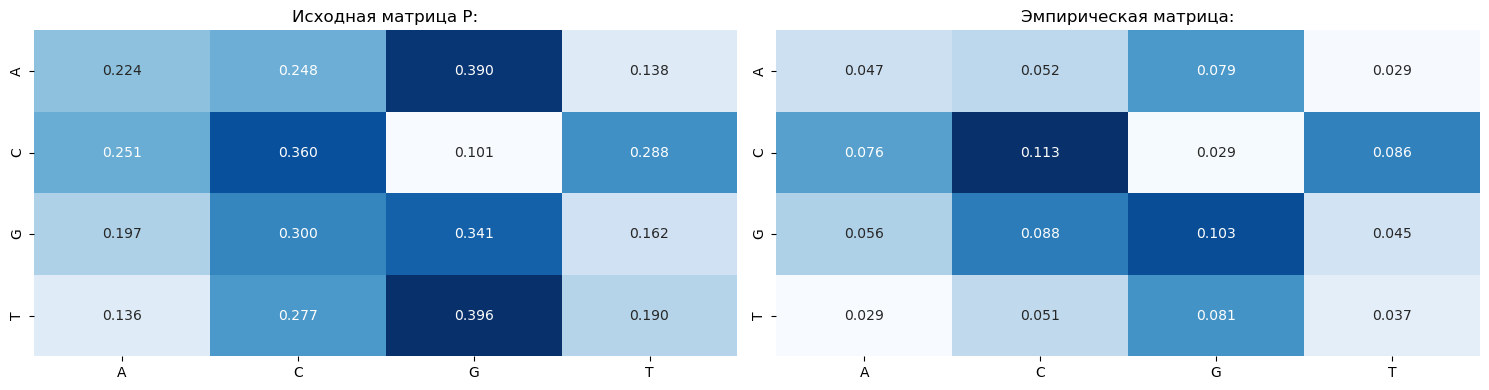

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Исходная матрица
sns.heatmap(P, annot=True, fmt='.3f', xticklabels=nucleotides, 
            yticklabels=nucleotides, ax=axes[0], cmap='Blues', cbar=False)
axes[0].set_title('Исходная матрица P:')

# Эмпирическая матрица
sns.heatmap(P_empirical, annot=True, fmt='.3f', xticklabels=nucleotides, 
            yticklabels=nucleotides, ax=axes[1], cmap='Blues', cbar=False)
axes[1].set_title('Эмпирическая матрица:')

plt.tight_layout()
plt.show()

Как видно из тепловых карт, эмпирическая матрица из сгенерированных последовательнсотей очень близка к исходной матрице переходов $P$. Это подтверждает, что написанный мной генератор работает корректно, т.е.марковская цепь адекватно вопроизводит реальную статистику.